In [17]:
import jax
import numpy as np
from numpy import load
import matplotlib as mpl
import matplotlib.pyplot as plt

In [18]:
classic_data = load('/Users/haydenoutlaw/Documents/Research/opnet/deep-operator-networks/CM2LA/results_classic/classic_results.npz')
lst = classic_data.files

for item in lst:
    print(item)
    print(classic_data[item])

loss_hist
[0.13938335 0.13936532 0.13934727 ... 0.05650405 0.05650065 0.05649724]
min_loss_hist
[0.13938335 0.13936532 0.13934727 ... 0.05650405 0.05650065 0.05649724]
l2_hist
[74.96974182 74.92121124 74.87274933 74.82434082 74.77597809 74.72766113
 74.67939758 74.63117218 74.58298492 74.5348587  74.48677826 74.43875122
 74.39078522 74.34285736 74.29499054 74.24716187 74.19939423 74.15167236
 74.10400391 74.05638885 74.00882721 73.9613266  73.91388702 73.86649323
 73.81916046 73.77188873 73.72467804 73.67752075 73.63041687 73.58338165
 73.53639221 73.48947144 73.44260406 73.39580536 73.34905243 73.30235291
 73.25571442 73.20913696 73.16261292 73.1161499  73.06973267 73.02337646
 72.97707367 72.93083191 72.88464355 72.83851624 72.79243469 72.74640656
 72.70043945 72.65451813 72.60865021 72.56283569 72.51707458 72.47137451
 72.42572021 72.38011932 72.33457184 72.28907776 72.24364471 72.19824219
 72.15290833 72.10762024 72.06238556 72.01718903 71.9720459  71.92695618
 71.88191986 71.83692

In [19]:
classic_data['loss_hist']

array([0.13938335, 0.13936532, 0.13934727, ..., 0.05650405, 0.05650065,
       0.05649724], shape=(10000,))

In [20]:
classic_data['min_loss_hist']

array([0.13938335, 0.13936532, 0.13934727, ..., 0.05650405, 0.05650065,
       0.05649724], shape=(10000,))

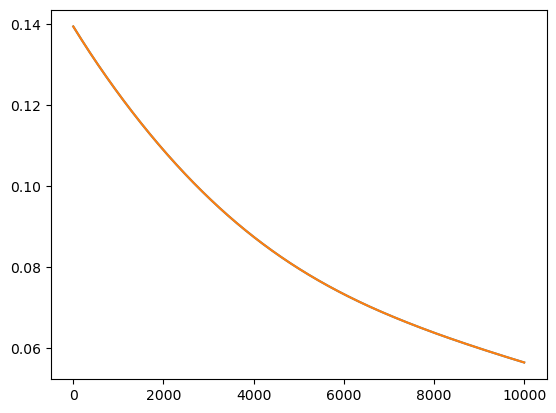

In [21]:
plt.plot(classic_data['min_loss_hist'])
plt.plot(classic_data['loss_hist'])

## VAE model basis renders

In [22]:
import yaml
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import matplotlib.pyplot as plt
from pathlib import Path
from jax.nn.initializers import he_normal

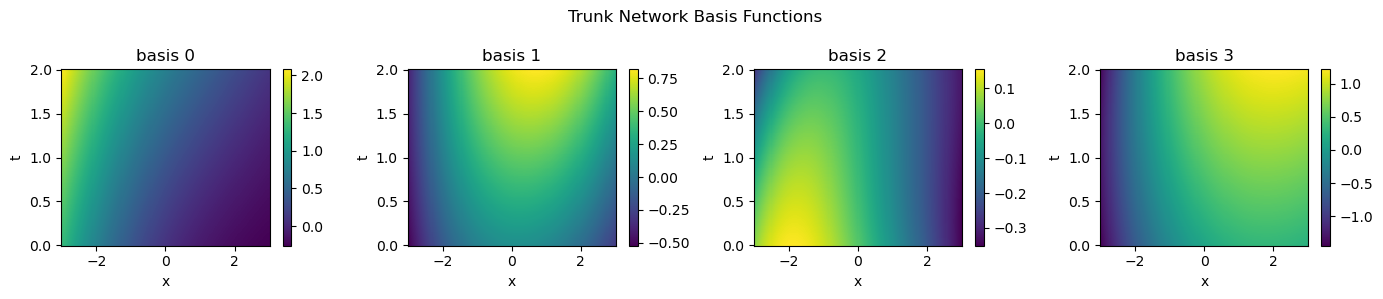

In [23]:
# ── same class definitions needed for deserialization ─────────────────────────

class Linear(eqx.Module):
    weight: jax.Array
    bias: jax.Array

    def __init__(self, in_size, out_size, key, initializer=he_normal()):
        wkey, bkey = jax.random.split(key)
        self.weight = initializer(wkey, (out_size, in_size), dtype=jnp.float32)
        self.bias = jnp.zeros((out_size,), dtype=jnp.float32)

    def __call__(self, x):
        return self.weight @ x + self.bias


class MLP(eqx.Module):
    layers: list
    activations: list

    def __init__(self, architecture, key, activation=jax.nn.gelu, initializer=he_normal()):
        keys = jax.random.split(key, len(architecture) - 1)
        self.layers = [
            Linear(architecture[i], architecture[i+1], keys[i], initializer=initializer)
            for i in range(len(architecture) - 1)
        ]
        self.activations = [activation] * (len(self.layers) - 1) + [eqx.nn.Identity()]

    def __call__(self, x):
        for layer, act in zip(self.layers, self.activations):
            x = act(layer(x))
        return x


# ── Load metadata ─────────────────────────────────────────────────────────────
results_dir = Path("../results_classic")
meta = np.load(results_dir / "classic_model_meta.npz")

t_grid     = jnp.array(meta['t_grid'])
x_grid     = jnp.array(meta['x_grid'])
trunk_arch  = meta['trunk_arch'].tolist()
branch_arch = meta['branch_arch'].tolist()
seed        = int(meta['seed'])

# ── Reconstruct model structure for deserialization ───────────────────────────
key = jax.random.key(seed)
key, subkey_t, subkey_b = jax.random.split(key, num=3)
trunk_model  = MLP(trunk_arch,  key=subkey_t)
branch_model = MLP(branch_arch, key=subkey_b)
model = trunk_model, branch_model

model = eqx.tree_deserialise_leaves(results_dir / "classic_model.eqx", model)
trunk_model, branch_model = model

# ── Evaluate trunk on full (t, x) grid ────────────────────────────────────────
tt, xx = jnp.meshgrid(t_grid, x_grid, indexing="ij")
tx_grid = jnp.stack([tt.reshape(-1), xx.reshape(-1)], axis=1)  # (T*X, 2)

T_MAT = jax.vmap(trunk_model)(tx_grid)  # (T*X, num_bases)
T_MAT = np.array(T_MAT).reshape(len(t_grid), len(x_grid), -1)  # (T, X, num_bases)

num_bases = T_MAT.shape[-1]

# ── Plot ───────────────────────────────────────────────────────────────────────
ncols = 4
nrows = (num_bases + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
axes = axes.flatten()

for i in range(num_bases):
    im = axes[i].pcolormesh(
        np.array(x_grid), np.array(t_grid), T_MAT[:, :, i],
        cmap='viridis', shading='auto'
    )
    axes[i].set_title(f"basis {i}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("t")
    plt.colorbar(im, ax=axes[i])

for j in range(num_bases, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Trunk Network Basis Functions")
plt.tight_layout()
plt.savefig(results_dir / "basis_functions.png", dpi=150)
plt.show()